In [1]:
from helpers.predictors import *

show = True

resolution = (1980, 1080)

video_name = 'gopro2_selected_hands_2'

in_file = f'inputs/{video_name}.mp4'
video_dir = f'inputs/{video_name}'
output_file = f'vis_dir/{video_name}'
exclude_box = None #[[610, 80, 795, 185]]
curr_obj_id = 0

c:\Users\fisv\AppData\Local\miniconda3\envs\openpose\Lib\site-packages\mmengine\optim\optimizer\zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \


Loads checkpoint by local backend from path: checkpoints/hands/detection/cascade_rcnn_x101_64x4d_fpn_20e_onehand10k-dac19597_20201030.pth


c:\Users\fisv\AppData\Local\miniconda3\envs\openpose\Lib\site-packages\mmengine\runner\checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.lo

Loads checkpoint by local backend from path: checkpoints/body/detection/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth


c:\Users\fisv\AppData\Local\miniconda3\envs\openpose\Lib\site-packages\mmengine\runner\checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.lo

In [2]:
bboxes_rtm, frame_idx_rtm = detect_bbox(in_file, show=show)
bboxes_rtm, frame_idx_rtm

inputs/gopro2_selected_hands_2.mp4
Never found hands


(array([], shape=(0, 4), dtype=float32), None)

In [3]:
bboxes_yolo, frame_idx_yolo = detect_bbox_yolo(in_file, exclude_box, write_folder=True, show=show)
bboxes_yolo, frame_idx_yolo

inputs/gopro2_selected_hands_2.mp4
hand with 0.98 confidence


(array([[910, 683, 961, 741]]), 0)

In [4]:
bboxes_in = bboxes_yolo
frame_idx = frame_idx_yolo
bboxes_in, frame_idx

(array([[910, 683, 961, 741]]), 0)

frame loading (JPEG): 100%|██████████| 751/751 [00:47<00:00, 15.86it/s]
C:\Users\fisv\source\repos\GitHub\segment-anything-2\sam2\modeling\sam\transformer.py:270: UserWarning: Memory efficient kernel not used because: (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:773.)
  out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p)
C:\Users\fisv\source\repos\GitHub\segment-anything-2\sam2\modeling\sam\transformer.py:270: UserWarning: Memory Efficient attention has been runtime disabled. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen/native/transformers/sdp_utils_cpp.h:558.)
  out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p)
C:\Users\fisv\source\repos\GitHub\segment-anything-2\sam2\modeling\sam\transformer.py:270: UserWarning: Flash attention kernel not used because: (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp

0


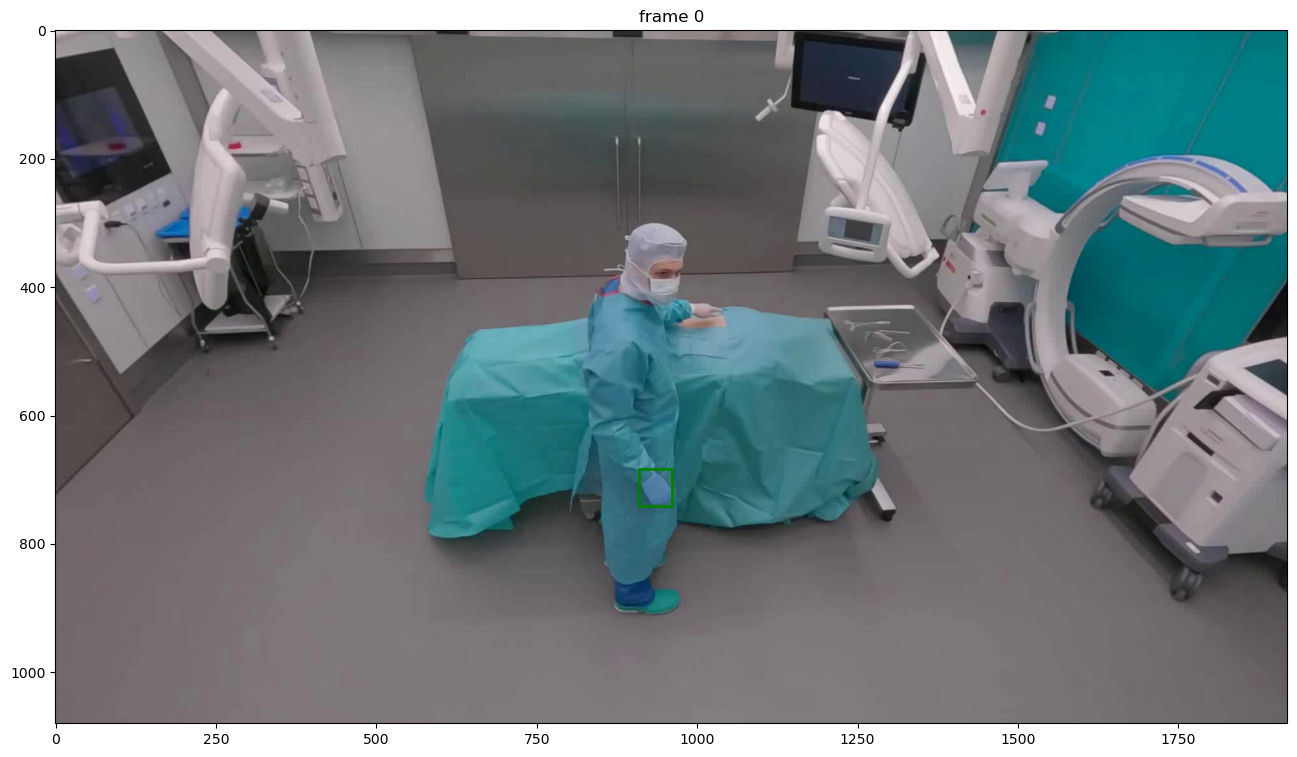

In [5]:
inference_state, predictor, frame_names = add_obj_to_sam(video_dir, bboxes_in[0], frame_idx, curr_obj_id, show=show)

In [6]:
video_segments, bboxes = track_with_sam(video_dir, inference_state, predictor, frame_names, show=show)

propagate in video: 100%|██████████| 751/751 [57:21<00:00,  4.58s/it]  


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


c:\Users\fisv\source\repos\ORPose\helpers\predictors.py:213: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(16, 9))


0
0
0
0
0
0


In [7]:
render_bbox_video(output_file, video_dir, bboxes, frame_names)

100%|██████████| 751/751 [03:02<00:00,  4.11it/s]


In [7]:
bboxes_yolo, frame_idx = detect_bbox_yolo(in_file, exclude_box, bboxes, write_folder=True, show=show)

inputs/gopro2_selected_hands_2.mp4
hand with 0.85 confidence


In [8]:
curr_obj_id = 1
curr_obj_id

1

frame loading (JPEG): 100%|██████████| 751/751 [00:49<00:00, 15.17it/s]


1


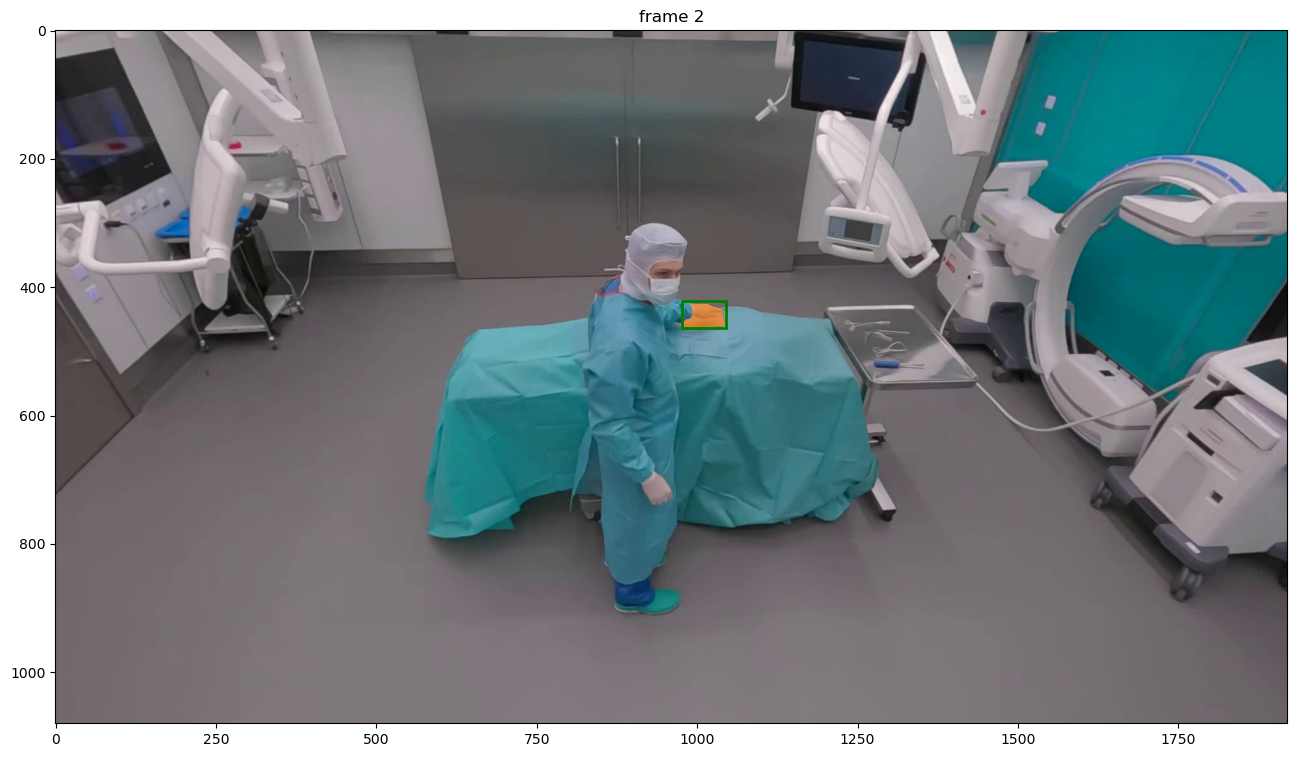

In [9]:
inference_state, predictor, frame_names = add_obj_to_sam(video_dir, bboxes_yolo[0], frame_idx, curr_obj_id, show=show)

In [10]:
prev_bboxes = bboxes

In [11]:
video_segments, bboxes = track_with_sam(video_dir, inference_state, predictor, frame_names, show=show, prev_bboxes=prev_bboxes)

propagate in video:   0%|          | 0/749 [00:00<?, ?it/s]

propagate in video: 100%|██████████| 3/3 [00:11<00:00,  3.70s/it]


1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [ ]:
render_bbox_video(output_file, video_dir, bboxes, frame_names)

100%|██████████| 751/751 [03:09<00:00,  3.97it/s]


In [12]:
import pickle

In [13]:
with open(f'bboxes/tracked_bboxes_{video_name}.pkl', 'wb+') as f:
    pickle.dump(bboxes, f)

In [14]:
for k, v in bboxes.items():
    v_new = {}
    for k2, v2 in v.items():
        if len(v2) > 0:
            v_new[k2] = v2
    bboxes[k] = v_new

In [15]:
bboxes

{0: {0: array([[913, 688, 964, 740]], dtype=int64),
  1: array([[ 974,  426, 1046,  465]], dtype=int64)},
 1: {0: array([[913, 689, 963, 741]], dtype=int64),
  1: array([[ 975,  426, 1046,  466]], dtype=int64)},
 2: {0: array([[913, 689, 963, 741]], dtype=int64),
  1: array([[ 977,  426, 1045,  465]], dtype=int64)},
 3: {0: array([[913, 688, 963, 741]], dtype=int64),
  1: array([[ 975,  427, 1045,  466]], dtype=int64)},
 4: {0: array([[913, 688, 963, 741]], dtype=int64),
  1: array([[ 975,  427, 1045,  466]], dtype=int64)},
 5: {0: array([[913, 688, 963, 741]], dtype=int64),
  1: array([[ 975,  426, 1046,  466]], dtype=int64)},
 6: {0: array([[913, 688, 962, 741]], dtype=int64),
  1: array([[ 976,  426, 1046,  466]], dtype=int64)},
 7: {0: array([[913, 688, 962, 741]], dtype=int64),
  1: array([[ 976,  425, 1046,  466]], dtype=int64)},
 8: {0: array([[913, 688, 963, 741]], dtype=int64),
  1: array([[ 976,  423, 1046,  466]], dtype=int64)},
 9: {0: array([[913, 688, 962, 741]], dtype=in